In [2]:
using Pkg
Pkg.activate(".")
Pkg.add(["Polyhedra", "CDDLib", "Plots", "HiGHS", "NEOSServer", "JuMP"])
Pkg.instantiate()
include("Polyhedron.jl")
using .Poly

  Activating project at `~/Documents/AreaDeTrabalho/mo vei/conj invariantes/Polyhedron`
   Resolving package versions...
  No Changes to `~/Documents/AreaDeTrabalho/mo vei/conj invariantes/Polyhedron/Project.toml`
  No Changes to `~/Documents/AreaDeTrabalho/mo vei/conj invariantes/Polyhedron/Manifest.toml`


In [3]:
# copie e cole os seus parâmetros

A = [0.9666 0;
    0.0328 0.9666] 
B = [0.1980;
    0.0033;;]

C = [0 1]

t = 0.5

delta = 0.8

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -t 1 t; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/15 0
      0 1/15;
     -1/15 0;
      0 -1/15;]
Sv = [1/300;
      -1/300;]

Sw = [1/15;
      -1/15;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

V = [1/4;
     -1/4;]

# Fr para a referência
R = [1/15;
      -1/15;;]
d = 2

2

declarar as variáveis para o sistema de tanques com atraso d = 2, delta = 0.8

In [4]:
result_1 = Poly.finding_L_pinvariant_segref_delay_sim2(A_exp, B_exp, E_exp, S, R, V, d, lambda=0.999, lf=24, time=30)

Job 18742400 dispatched
password: qsfoUEHR
---------- Begin Solver Output -----------
Condor submit: 'neos.submit'
Condor submit: 'watchdog.submit'

Job submitted to NEOS HTCondor pool.

OTHER_LIMIT

Dict{String, Matrix{Float64}} with 36 entries:
  "P_diff" => [0.000500518 -0.000500518; -7.71119e-8 7.71119e-8; … ; 0.00021962…
  "Zm"     => [149.856 149.77 … 149.845 149.848; 149.846 149.152 … 149.847 149.…
  "P_sum"  => [0.0092856 0.0092856; -6.58578e-8 -6.58578e-8; … ; 0.0101422 0.01…
  "U_sum"  => [1.39033e-7 0.0479498 … 1.37342e-7 1.75427e-7; 1.39033e-7 0.04794…
  "Um"     => [6.07957e-8 3.39014e-8 … 6.80948e-8 4.75881e-8; 7.82376e-8 0.0479…
  "Zp"     => [149.837 149.923 … 149.848 149.845; 149.848 150.541 … 149.847 149…
  "M_diff" => [4.48483e-7 4.81152e-6 … 4.21369e-9 2.25692e-7; -1.68308e-8 -1.08…
  "Hp"     => [0.00535721 0.108261 … 0.0044973 0.00468167; -3.13685e-8 0.947556…
  "Tp"     => [9.88716e-7 3.63252e-7 … 1.32383e-6 1.11059e-6; 3.30474e-7 0.3233…
  "Z_sum"  => [299.693 299.693 … 299.693 299.693; 299.693 299.693 … 299.693 299…
  "H_diff" => [0.0015306 0.106893 … 3.86811e-6 0.000300292; 8.64086e-9 0.947556…
  "Mm"     => [0.00224372 0.00224154 … 0.00224395 0.00224383; 

In [5]:
using LinearAlgebra

F = result_1["F"]
F = vcat(F, -F)

48×4 Matrix{Float64}:
 -0.00255189    0.0202918    -0.000558337   0.000333678
  0.000251521   0.185217     -0.00533171   -2.70694e-6
 -0.106365     -0.0494079     0.00342578    0.024387
 -0.108116     -0.0708561     0.00382026    0.0159498
  0.0203762     0.00630836   -0.0015151    -0.00319715
  7.44711e-8    2.61773e-8    2.46537e-6   -0.0666651
  0.0242931     0.0452897    -0.00172073   -0.0487022
 -0.0627026    -0.051885      0.00397894   -0.000246372
 -0.00790895   -0.00421123    0.000382223   0.0110937
  0.0655631    -0.016954     -0.00114296   -0.0059359
 -0.0023569    -0.00436779    0.000129892   0.000732327
  0.00656777    0.00562376   -0.00029315   -0.00098764
  4.1171e-8     2.08807e-8   -0.00333263   -4.65649e-6
  ⋮                                        
 -4.1171e-8    -2.08807e-8    0.00333263    4.65649e-6
 -0.0285195    -0.0198902     0.00111626    0.00795307
 -0.0649308     0.0231855     0.000978535   0.0130884
 -0.0622281    -0.0367847     0.00228297    0.0267282
  0.3

In [6]:
G = result_1["G"]

1×4 Matrix{Float64}:
 -0.762713  -0.724412  0.0349323  0.106491

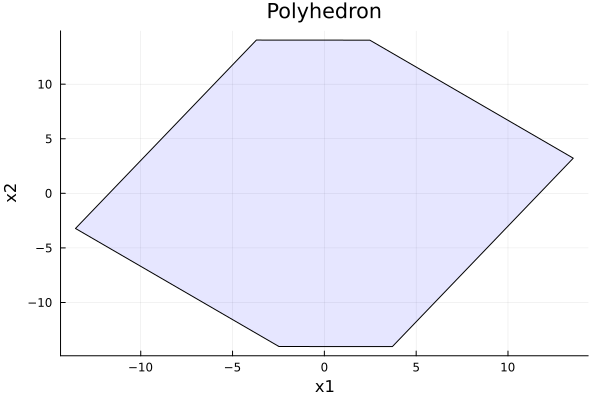

In [7]:
T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

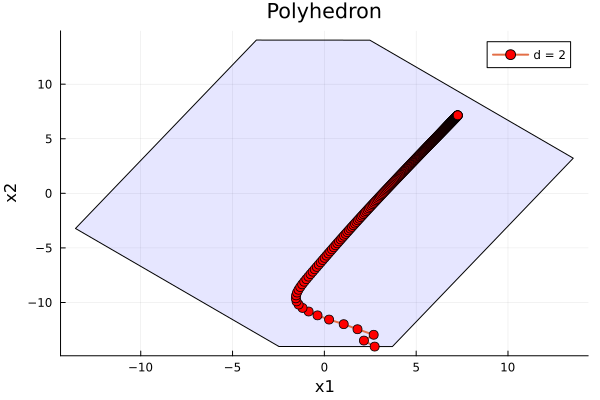

In [26]:
using Plots

w = ones(size(F, 1))
nx = size(A_exp, 1)

passos = 300
r = ones(passos)*7.4 # escolher a referência a se seguir 

BG = B_exp * G

init_cond_F, init_cond_w = Poly.admissable_initCond(A_exp, BG, F, d, w; fixed_d=true)
ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F, init_cond_w, 3, nx)
traj = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=false)

Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

x1 = [p[1] for p in traj]
x2 = [p[2] for p in traj]
v = [p[3] for p in traj]
w = [p[4] for p in traj]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 2",
     xlabel = "x1",
     ylabel = "x2")

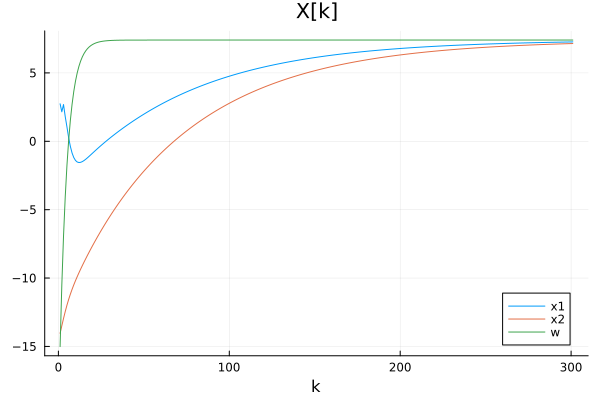

In [27]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

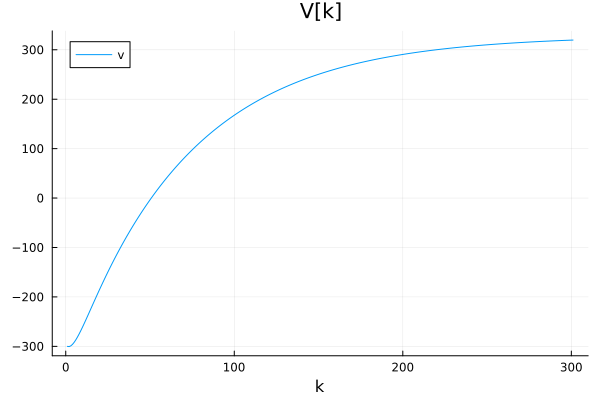

In [28]:
plot(v,
     label="v",
     xlabel="k",
     title="V[k]")

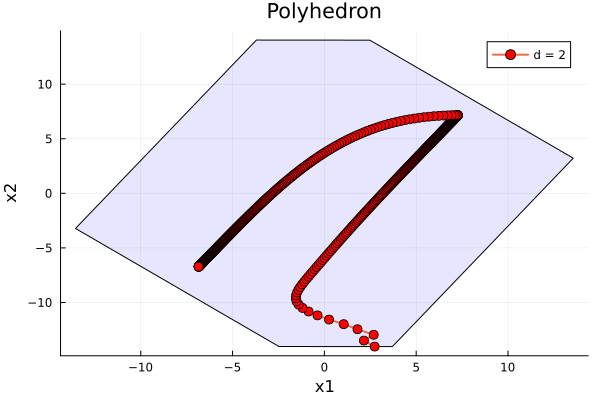

In [29]:
r = ones(passos)* -7
a = Vector{Tuple{Float64, Float64, Float64, Float64}}(undef, 2)
fill!(a, (0.0, 0.0, 0.0, 0.0))
traj_temp = vcat(a, traj)
traj2 = Poly.trajectory_segref_delay(traj_temp, A_exp, BG, E_exp, r, passos, d; reverse=false)

Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

x1 = [p[1] for p in traj2]
x2 = [p[2] for p in traj2]
v = [p[3] for p in traj2]
w = [p[4] for p in traj2]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 2",
     xlabel = "x1",
     ylabel = "x2")

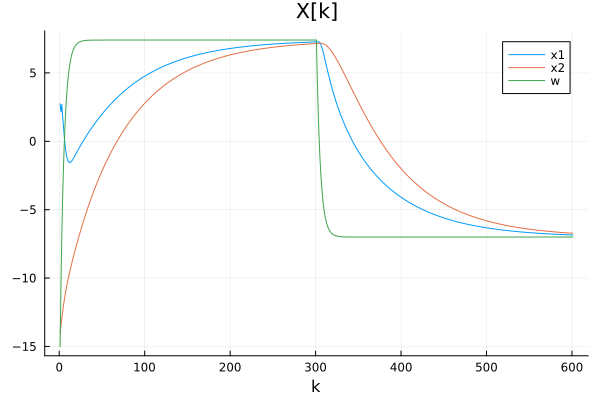

In [30]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

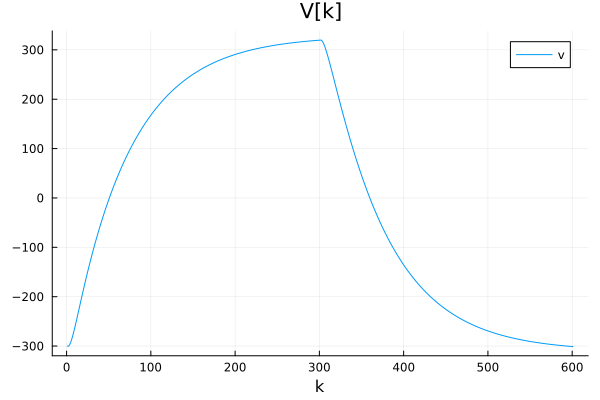

In [31]:
plot(v,
     label="v",
     xlabel="k",
     title="V[k]")

Computed u for traj; length = 301


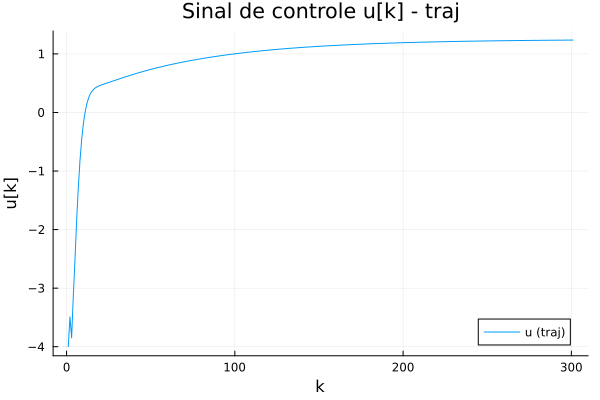

In [32]:
# Cálculo simples do sinal de controle usando `Gx = G[:, 1:2]`
using Plots

# Calcular u para `traj` (assume que `traj` existe)
u = [(G * [p[1]; p[2]; p[3]; p[4]])[1] for p in traj]
println("Computed u for traj; length = ", length(u))
plot(u, label = "u (traj)", xlabel = "k", ylabel = "u[k]", title = "Sinal de controle u[k] - traj")

Computed u2 for traj2; length = 601


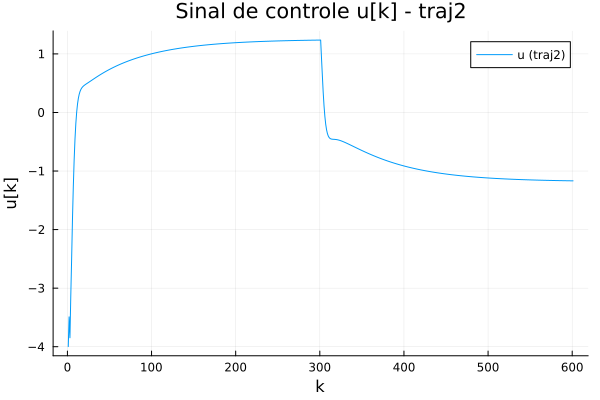

In [33]:
# Calcular u2 para `traj2` (assume que `traj2` existe)
u2 = [(G * [p[1]; p[2]; p[3]; p[4]])[1] for p in traj2]
println("Computed u2 for traj2; length = ", length(u2))
plot(u2, label = "u (traj2)", xlabel = "k", ylabel = "u[k]", title = "Sinal de controle u[k] - traj2")


In [41]:
using MAT

# Converte traj e traj2 (vetor de tuplas) para matrizes Nx4
traj_mat = traj isa Vector && !isempty(traj) ? vcat([collect(p)' for p in traj]...) : zeros(0,4)
traj2_mat = traj2 isa Vector && !isempty(traj2) ? vcat([collect(p)' for p in traj2]...) : zeros(0,4)

# Abre o arquivo .mat para escrita
file = matopen("saved_simulation2.mat", "w")

# Salva escalares e arrays
write(file, "d", d)
write(file, "t", t)
write(file, "delta", delta)
write(file, "passos", passos)

write(file, "A", A)
write(file, "B", B)
write(file, "C", C)

write(file, "A_exp", A_exp)
write(file, "B_exp", B_exp)
write(file, "E_exp", E_exp)

write(file, "S", S)
write(file, "R", R)
write(file, "F", F)
write(file, "G", G)

# T: se for array/Matrix, salva; se for otro tipo, tenta converter ou omite
try
    write(file, "T", T)
catch
    println("T não pôde ser salvo como array.")
end

write(file, "init_cond_F", init_cond_F)
write(file, "init_cond_w", init_cond_w)

# Trajetórias e controles
write(file, "traj", traj_mat)
write(file, "traj2", traj2_mat)
write(file, "u", u)
write(file, "u2", u2)

close(file)

println("Variáveis exportadas para saved_simulation2.mat")

Variáveis exportadas para saved_simulation2.mat


In [40]:
using DelimitedFiles

# Converte vetores de tuplas para matrizes (se ainda não forem)
traj_mat  = vcat([collect(p)' for p in traj]...)
traj2_mat = vcat([collect(p)' for p in traj2]...)

outfname = "saved_simulation2.txt"
open(outfname, "w") do io
    println(io, "=== d ===")
    writedlm(io, [d])

    println(io, "=== t ===")
    writedlm(io, [t])

    println(io, "=== delta ===")
    writedlm(io, [delta])

    println(io, "=== passos ===")
    writedlm(io, [passos])

    println(io, "=== A ===")
    writedlm(io, A)

    println(io, "=== B ===")
    writedlm(io, B)

    println(io, "=== C ===")
    writedlm(io, C)

    println(io, "=== A_exp ===")
    writedlm(io, A_exp)

    println(io, "=== B_exp ===")
    writedlm(io, B_exp)

    println(io, "=== E_exp ===")
    writedlm(io, E_exp)

    println(io, "=== S ===")
    writedlm(io, S)

    println(io, "=== R ===")
    writedlm(io, R)

    println(io, "=== F ===")
    writedlm(io, F)

    println(io, "=== G ===")
    writedlm(io, G)

    println(io, "=== T (poly projection) ===")
    try
        writedlm(io, T)
    catch
        println(io, "(T não é gravável diretamente como matriz)")
    end

    println(io, "=== init_cond_F ===")
    writedlm(io, init_cond_F)

    println(io, "=== init_cond_w ===")
    writedlm(io, init_cond_w)

    println(io, "=== traj (Nx4) ===")
    writedlm(io, traj_mat)

    println(io, "=== traj2 (Nx4) ===")
    writedlm(io, traj2_mat)

    println(io, "=== u ===")
    writedlm(io, u)

    println(io, "=== u2 ===")
    writedlm(io, u2)
end

println("Variáveis salvas em ", outfname)

Variáveis salvas em saved_simulation2.txt
